# V3 — Feature Engineering — 1H BTC/USDT

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = (Path.cwd() / "../..").resolve()
sys.path.insert(0, str(PROJECT_ROOT))

import yaml
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
plt.style.use("seaborn-v0_8-darkgrid")
print(f"Project root: {PROJECT_ROOT}")


Project root: /Users/nuwan/Work/UoM/MDSAI_2025/semester3/capstone-project/project/reinforcement-based-cryptocurrency-trading-strategy


## 1. Load Feature Data

In [2]:
train = pd.read_csv(PROJECT_ROOT / "data/features/train.csv", index_col=0, parse_dates=True)
val   = pd.read_csv(PROJECT_ROOT / "data/features/val.csv",   index_col=0, parse_dates=True)
test  = pd.read_csv(PROJECT_ROOT / "data/features/test.csv",  index_col=0, parse_dates=True)
print(f"Columns: {train.columns.tolist()}")
print(f"Train: {len(train):,} rows  {train.index[0].date()} → {train.index[-1].date()}")
print(f"Val  : {len(val):,} rows")
print(f"Test : {len(test):,} rows")


Columns: ['open', 'high', 'low', 'close', 'volume', 'sma_10', 'sma_50', 'rsi', 'momentum_5', 'close_return', 'open_gap', 'high_dev', 'low_dev', 'log_volume', 'sma_10_dev', 'sma_50_dev']
Train: 23,326 rows  2022-01-03 → 2024-08-31
Val  : 720 rows
Test : 2,208 rows


## 2. Feature Statistics (V3)

In [3]:
# V3 observation features — return-based OHLCV + SMA deviations
v3_cols = [
    "close_return", "open_gap", "high_dev", "low_dev", "log_volume",
    "sma_10_dev", "sma_50_dev", "rsi", "momentum_5",
]
train[v3_cols].describe().round(5)


,close_return,open_gap,high_dev,low_dev,log_volume,sma_10_dev,sma_50_dev,rsi,momentum_5
count,23326.00000,23326.00000,23326.00000,23326.00000,23326.00000,23326.00000,23326.00000,23326.00000,23326.00000
mean,0.00003,-0.00000,0.00376,-0.00389,7.69597,-0.00003,-0.00018,50.27350,0.01305
std,0.00579,0.00002,0.00452,0.00443,1.12586,0.00970,0.02353,12.23946,1.28354
min,-0.06989,-0.00040,0.00000,-0.06664,0.00000,-0.09260,-0.23025,5.56057,-10.62347
25%,-0.00206,-0.00000,0.00114,-0.00494,6.81726,-0.00334,-0.00971,42.54594,-0.45373
50%,0.00004,0.00000,0.00242,-0.00262,7.50819,0.00007,0.00010,50.20561,0.01041
75%,0.00217,0.00000,0.00474,-0.00124,8.59182,0.00342,0.01030,57.63247,0.48135
max,0.06487,0.00048,0.08375,0.00000,11.82925,0.06703,0.11850,91.84223,9.84658


## 3. SMA Crossovers (Train)

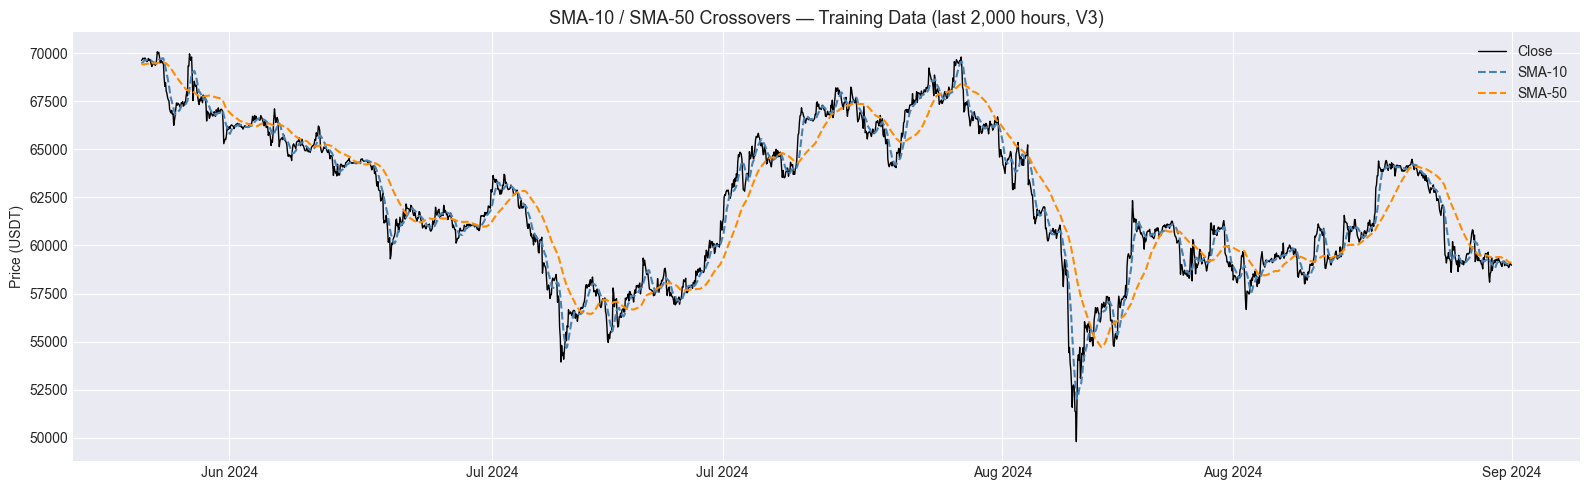

In [4]:
sample = train.tail(2000)
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(sample.index, sample["close"],  label="Close",  linewidth=1.0, color="black")
ax.plot(sample.index, sample["sma_10"], label="SMA-10", linewidth=1.5, color="steelblue", linestyle="--")
ax.plot(sample.index, sample["sma_50"], label="SMA-50", linewidth=1.5, color="darkorange", linestyle="--")
ax.set_title("SMA-10 / SMA-50 Crossovers — Training Data (last 2,000 hours, V3)", fontsize=13)
ax.set_ylabel("Price (USDT)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.legend()
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "results/figures/v3_02_sma_crossovers.png", dpi=150)
plt.show()


## 4. SMA Deviations — New V3 Feature

`sma_10_dev = (close − sma_10) / close` — positive when close is above the moving average (bullish signal), negative when below. Scale-invariant: works at $20k or $200k without re-fitting a scaler.

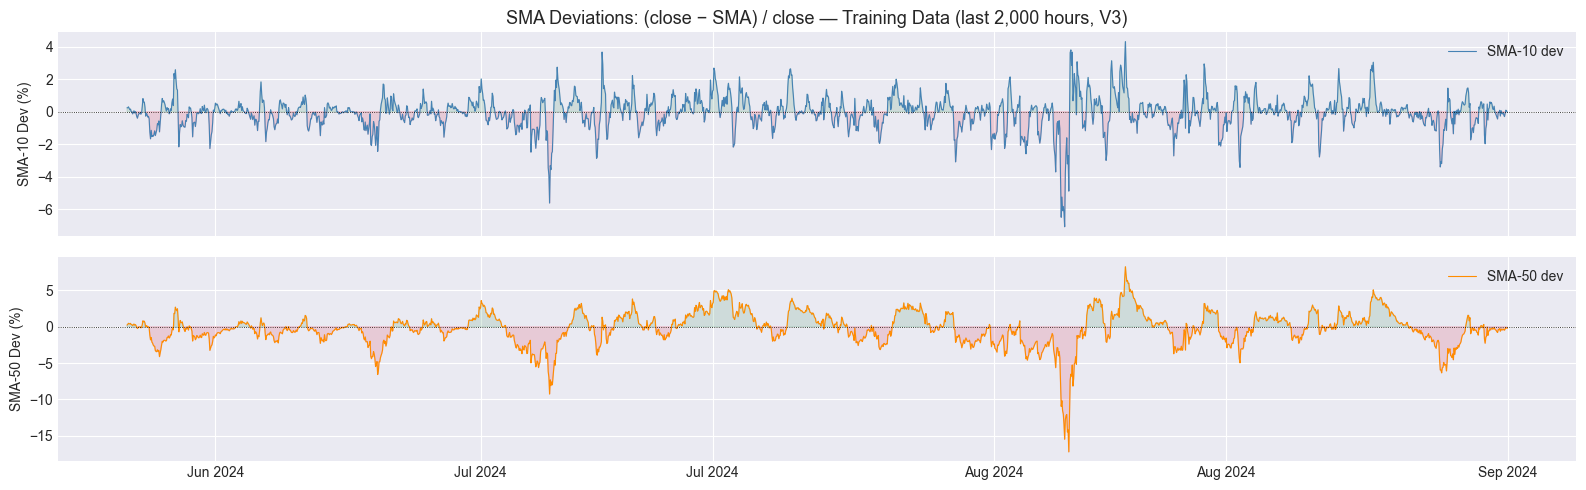

In [5]:
sample = train.tail(2000)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 5), sharex=True,
                               gridspec_kw={"height_ratios": [1, 1]})

ax1.plot(sample.index, sample["sma_10_dev"] * 100, color="steelblue", linewidth=0.8, label="SMA-10 dev")
ax1.axhline(0, color="black", linewidth=0.6, linestyle=":")
ax1.fill_between(sample.index, 0, sample["sma_10_dev"] * 100,
                 where=sample["sma_10_dev"] > 0, alpha=0.15, color="seagreen")
ax1.fill_between(sample.index, 0, sample["sma_10_dev"] * 100,
                 where=sample["sma_10_dev"] < 0, alpha=0.15, color="crimson")
ax1.set_ylabel("SMA-10 Dev (%)")
ax1.set_title("SMA Deviations: (close − SMA) / close — Training Data (last 2,000 hours, V3)", fontsize=13)
ax1.legend()

ax2.plot(sample.index, sample["sma_50_dev"] * 100, color="darkorange", linewidth=0.8, label="SMA-50 dev")
ax2.axhline(0, color="black", linewidth=0.6, linestyle=":")
ax2.fill_between(sample.index, 0, sample["sma_50_dev"] * 100,
                 where=sample["sma_50_dev"] > 0, alpha=0.15, color="seagreen")
ax2.fill_between(sample.index, 0, sample["sma_50_dev"] * 100,
                 where=sample["sma_50_dev"] < 0, alpha=0.15, color="crimson")
ax2.set_ylabel("SMA-50 Dev (%)")
ax2.legend()
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "results/figures/v3_02_sma_deviations.png", dpi=150)
plt.show()


## 5. RSI

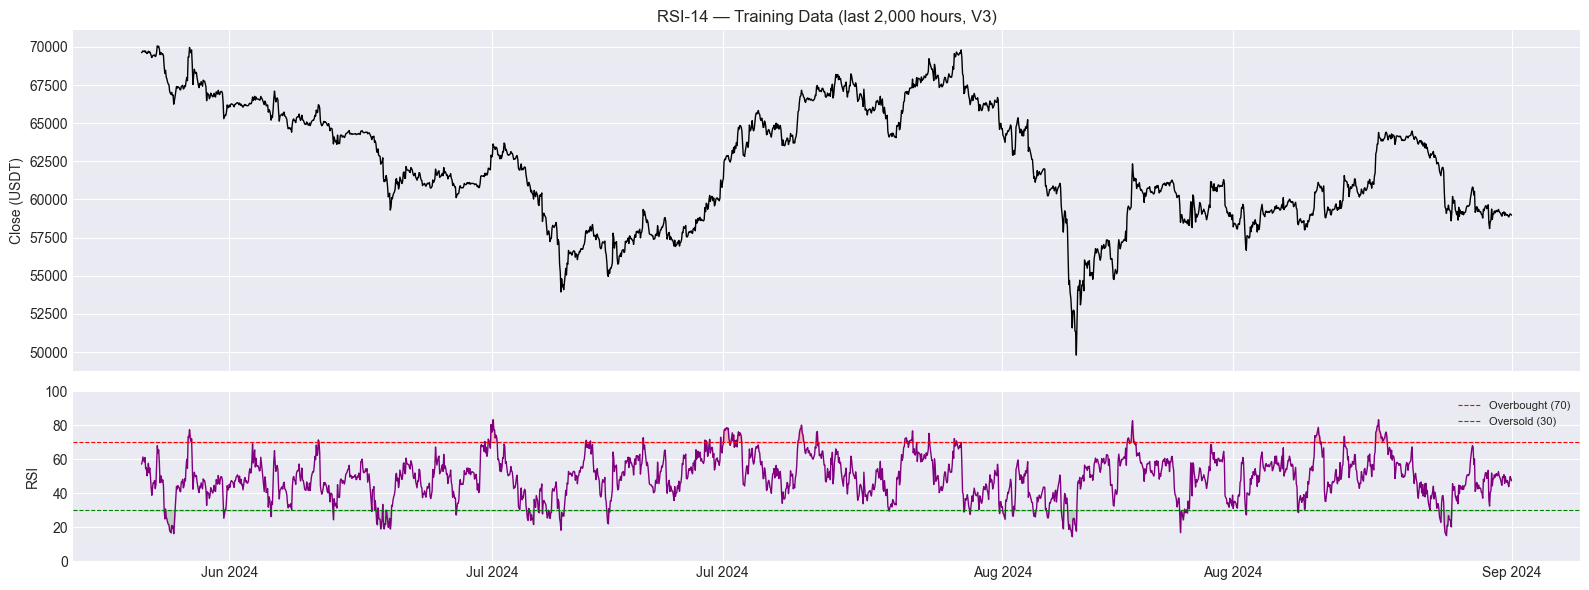

In [6]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 6), sharex=True,
                               gridspec_kw={"height_ratios": [2, 1]})
sample = train.tail(2000)
ax1.plot(sample.index, sample["close"], color="black", linewidth=1.0)
ax1.set_ylabel("Close (USDT)")
ax1.set_title("RSI-14 — Training Data (last 2,000 hours, V3)")
ax2.plot(sample.index, sample["rsi"], color="purple", linewidth=1.0)
ax2.axhline(70, color="red",   linewidth=0.8, linestyle="--", label="Overbought (70)")
ax2.axhline(30, color="green", linewidth=0.8, linestyle="--", label="Oversold (30)")
ax2.fill_between(sample.index, 70, sample["rsi"].clip(70), alpha=0.2, color="red")
ax2.fill_between(sample.index, sample["rsi"].clip(upper=30), 30, alpha=0.2, color="green")
ax2.set_ylabel("RSI")
ax2.set_ylim(0, 100)
ax2.legend(loc="upper right", fontsize=8)
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "results/figures/v3_02_rsi.png", dpi=150)
plt.show()


## 6. Momentum

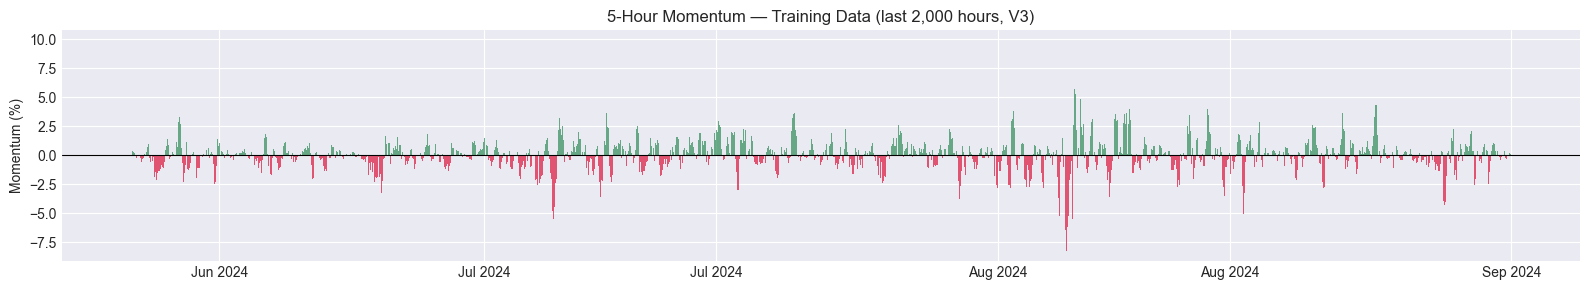

In [7]:
fig, ax = plt.subplots(figsize=(16, 3))
sample = train.tail(2000)
ax.bar(sample.index, sample["momentum_5"],
       color=["seagreen" if v >= 0 else "crimson" for v in sample["momentum_5"]],
       width=0.04, alpha=0.7)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("5-Hour Momentum — Training Data (last 2,000 hours, V3)")
ax.set_ylabel("Momentum (%)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "results/figures/v3_02_momentum.png", dpi=150)
plt.show()


## 7. Return Features — New V3 Features

Distributions of the four return-based features that replace absolute OHLCV. Hourly BTC returns cluster tightly around 0% regardless of whether the absolute price is $20k or $100k, making these features stationary and OOD-safe.

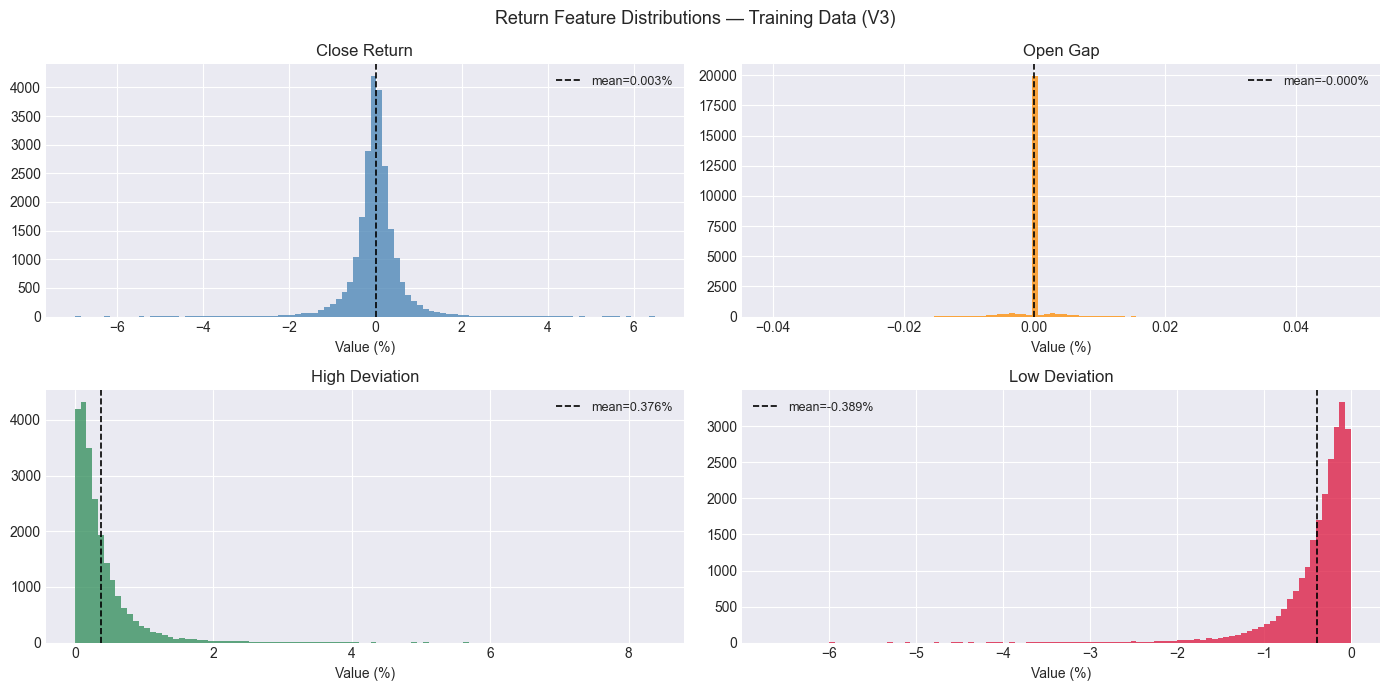

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 7))
features = [
    ("close_return", "Close Return",  "steelblue"),
    ("open_gap",     "Open Gap",      "darkorange"),
    ("high_dev",     "High Deviation", "seagreen"),
    ("low_dev",      "Low Deviation",  "crimson"),
]
for ax, (col, label, color) in zip(axes.flat, features):
    data = train[col].dropna() * 100
    ax.hist(data, bins=100, color=color, alpha=0.75, edgecolor="none")
    ax.axvline(data.mean(), color="black", linewidth=1.2, linestyle="--",
               label=f"mean={data.mean():.3f}%")
    ax.set_title(label)
    ax.set_xlabel("Value (%)")
    ax.legend(fontsize=9)
plt.suptitle("Return Feature Distributions — Training Data (V3)", fontsize=13)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "results/figures/v3_02_return_distributions.png", dpi=150)
plt.show()


## 8. Feature Correlation (V3)

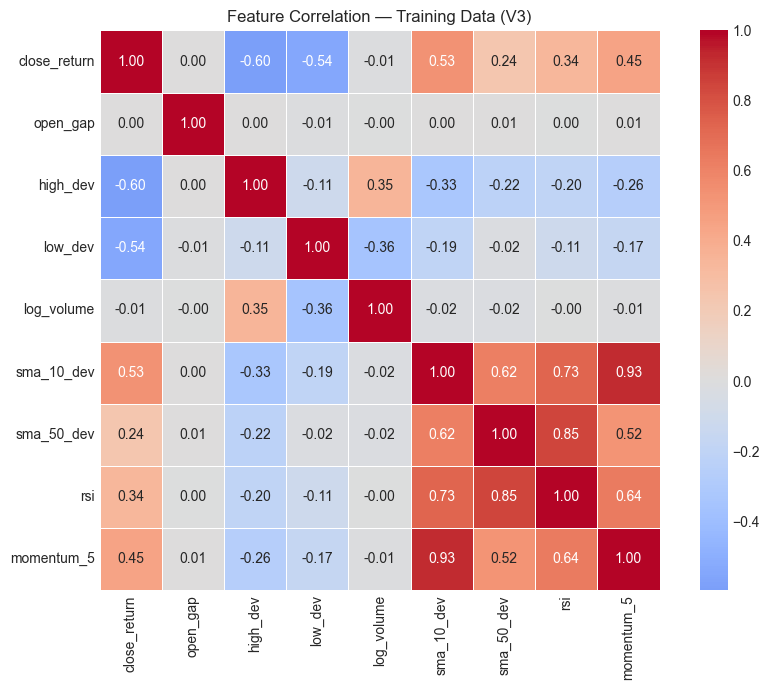

In [9]:
fig, ax = plt.subplots(figsize=(9, 7))
v3_cols = [
    "close_return", "open_gap", "high_dev", "low_dev", "log_volume",
    "sma_10_dev", "sma_50_dev", "rsi", "momentum_5",
]
corr = train[v3_cols].corr()
sns_import = __import__("seaborn")
sns_import.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
                   ax=ax, square=True, linewidths=0.5)
ax.set_title("Feature Correlation — Training Data (V3)")
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "results/figures/v3_02_correlation.png", dpi=150)
plt.show()


## 9. Normalised Data Check (V3)

In [10]:
train_norm = pd.read_csv(PROJECT_ROOT / "data/normalized/train.csv", index_col=0, parse_dates=True)
val_norm   = pd.read_csv(PROJECT_ROOT / "data/normalized/val.csv",   index_col=0, parse_dates=True)
test_norm  = pd.read_csv(PROJECT_ROOT / "data/normalized/test.csv",  index_col=0, parse_dates=True)

norm_cols = ["close_return", "open_gap", "high_dev", "low_dev", "log_volume",
             "sma_10_dev", "sma_50_dev"]

print("Normalised range check (MinMaxScaled return features + SMA deviations):")
print(f"{'Column':<16} {'Train [min, max]':>22}  {'Val [min, max]':>22}  {'Test [min, max]':>22}")
for col in norm_cols:
    tr = f"[{train_norm[col].min():.4f}, {train_norm[col].max():.4f}]"
    vl = f"[{val_norm[col].min():.4f},  {val_norm[col].max():.4f}]"
    te = f"[{test_norm[col].min():.4f},  {test_norm[col].max():.4f}]"
    print(f"  {col:<16} {tr:>22}  {vl:>22}  {te:>22}")

print("\nTrain return features are exactly [0,1] (scaler fit on train).")
print("Val/test values within range = no OOD clipping needed (return features are regime-stable).")


Normalised range check (MinMaxScaled return features + SMA deviations):
Column                 Train [min, max]          Val [min, max]         Test [min, max]
  close_return           [0.0000, 1.0000]       [0.3643,  0.6821]       [0.2683,  0.7506]
  open_gap               [0.0000, 1.0000]       [0.4279,  0.4796]       [0.4156,  0.5639]
  high_dev               [0.0000, 1.0000]       [0.0000,  0.3056]       [0.0000,  0.4701]
  low_dev                [0.0000, 1.0000]       [0.6421,  1.0000]       [0.0540,  1.0000]
  log_volume             [0.0000, 1.0000]       [0.4092,  0.7675]       [0.3833,  0.8092]
  sma_10_dev             [0.2685, 0.6676]       [0.4182,  0.5750]       [0.4023,  0.6245]
  sma_50_dev             [0.1163, 0.6975]       [0.3907,  0.5747]       [0.3662,  0.6439]

Train return features are exactly [0,1] (scaler fit on train).
Val/test values within range = no OOD clipping needed (return features are regime-stable).
